<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab11_NLP_towards_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Is a *queen* really just a *king*, minus a *man*, plus a *woman*?**

--------------



In class, we dealt with **embeddings** trained for **sentiment classification**. These embeddings are optimized to separate *positive* from *negative* expressions and **do not encode deeper semantic information**.

However, in modern natural language processing, there exist other embeddings — such as those from **BERT**, **word2vec**, or **GloVe** — that **do capture semantic structure**. These models are trained on large corpora, and their embeddings often allow for meaningful **vector arithmetic**, like the famous:

```
embedding("king") - embedding("man") + embedding("woman") ≈ embedding("queen")
```

This homework explores **semantic vector relationships** using such pretrained embeddings.

## **The Objective**

Your task is to:

1. Construct semantic classes of word pairs.
2. Visualize them using PCA.
3. Explore arithmetic operations in embedding space.

## **Tasks & Deliverables**

### 1. **Semantic Pair Classes**

- You must gather **at least 10 classes** of semantically related word pairs.
- Each class must contain **at least 5 pairs**.
- That gives a **minimum total of 100 unique words** (10 classes x 5 pairs x 2 words per pair).

Two example classes:

**Class 1: Gender**

- (king, queen)
- (man, woman)
- (doctor, nurse)
- (prince, princess)
- *(you must add one more)*

**Class 2: Verb tense (past tense)**

- (bring, brought)
- (get, got)
- (like, liked)
- *(you must add two more)*

**Your job:**

- Invent or search for **at least 10 such classes**, including the examples above.
- Each class must be conceptually coherent.
- Other examples: singular/plural, country/capital, comparative/superlative, tool/user, job/object, etc.

### 2. **Global PCA (Across All Words)**

- Use PCA to reduce the **entire set of 100 word embeddings** to 2D, and plot it.
- Plot the additional **10 separate charts**, one for each class.
  - Each chart should display only the 10 words (5 pairs) of the given class.
- Points should be labeled with the words themselves.
- Use arrows to indicate matching pairs of points.

### 3. **Local PCA (Per Class)**

- For each class (10 total), perform PCA **only** on the 10 words of that class.
- Plot these class-wise PCA visualizations as separate charts.
- Again, points should be labeled with the words.
- Use arrows to indicate matching pairs of points.

**Total: 21 charts**
(1 global plot with 100 words + 10 global-space class plots + 10 local PCA class plots)

Charts should be presented in a self-explanatory manner with clear labels.

### 4. **Embedding Arithmetic**

For each class, choose **one example pair** (e.g., (king, queen)) and perform the operation:

```
embedding(B) - embedding(A) + embedding(C)
```

Where A and B form a known pair, and C is another base word.
For example:

```
embedding("king") - embedding("man") + embedding("woman")
```

* For each such result vector, find the **5 closest word embeddings** (using cosine similarity or Euclidean distance).
* Print the top 5 neighbors **with their distances**.
* Do this **once per class** (i.e., 10 times).

This will make it possible to verify if
 ```
embedding("queen") ≈ embedding("king") - embedding("man") + embedding("woman")
```
for the *gender*-related class.


### 5. **Discussion**

* Analyze and interpret your 21 plots.
* Discuss whether the vector relationships are preserved.
* Does PCA capture semantic differences?
* Are the closest words from the arithmetic meaningful?
* **Two very important points to include in the discussion:**
  1. What kinds of relationships are captured, and what are not?
  2. Are some classes better behaved than others?


### 6. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.


## Acknowledgments

*This homework assignment was inspired by an idea from my master's student **Andrzej Małek**, to whom I would like to express my thanks.*



#Solution

In [47]:
classes = {
    "Gender": [
        ("king", "queen"),
        ("man", "woman"),
        ("boy", "girl"),
        ("prince", "princess"),
        ("actor", "actress")
    ],
    "Past tense": [
        ("go", "went"),
        ("eat", "ate"),
        ("run", "ran"),
        ("write", "wrote"),
        ("bring", "brought")
    ],
    "Plural": [
        ("car", "cars"),
        ("dog", "dogs"),
        ("house", "houses"),
        ("tree", "trees"),
        ("book", "books")
    ],
    "Capitals of countries": [
        ("france", "paris"),
        ("poland", "warsaw"),
        ("japan", "tokyo"),
        ("germany", "berlin"),
        ("italy", "rome")
    ],
    "Comparison of adjectives": [
        ("big", "bigger"),
        ("small", "smaller"),
        ("fast", "faster"),
        ("strong", "stronger"),
        ("cold", "colder")
    ],
    "Opposites": [
        ("fast", "slow"),
        ("good", "bad"),
        ("happy", "sad"),
        ("light", "dark"),
        ("young", "old")
    ],
    "Professions and workplaces": [
        ("teacher", "school"),
        ("doctor", "hospital"),
        ("chef", "restaurant"),
        ("pilot", "airport"),
        ("farmer", "farm")
    ],
    "Tools and professions": [
        ("brush", "painter"),
        ("pen", "writer"),
        ("camera", "photographer"),
        ("hammer", "carpenter"),
        ("syringe", "nurse")
    ],
    "Animal sounds": [
        ("snake", "hiss"),
        ("cat", "meow"),
        ("cow", "moo"),
        ("duck", "quack"),
        ("bee", "buzz")
    ],
    "Materials and products": [
        ("wood", "table"),
        ("cotton", "shirt"),
        ("glass", "window"),
        ("steel", "bridge"),
        ("wool", "coat")
    ]
}

In [48]:
!pip install gensim

In [49]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")

all_words = []

for pairs in classes.values():
    for a, b in pairs:
        all_words.extend([a, b])

embeddings = np.array([model[word] for word in all_words])

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

global_2d = pca.fit_transform(embeddings)

In [51]:
import matplotlib.pyplot as plt

def plot_pairs(words, coords, pairs, title):
    plt.figure(figsize=(10, 8))

    word_to_coord = {
        word: coords[i]
        for i, word in enumerate(words)
    }

    for word, (x, y) in word_to_coord.items():
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, word)

    for a, b in pairs:
        x1, y1 = word_to_coord[a]
        x2, y2 = word_to_coord[b]

        plt.arrow(
            x1, y1,
            x2 - x1,
            y2 - y1,
            head_width=0.02,
            length_includes_head=True
        )

    plt.title(title)
    plt.grid(True)
    plt.show()

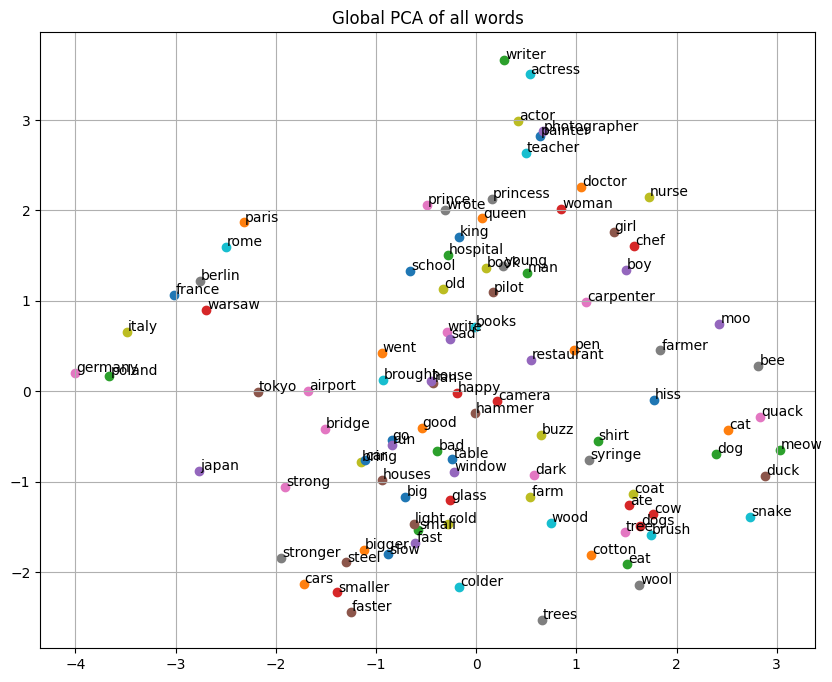

In [52]:
plot_pairs(
    all_words,
    global_2d,
    [],
    "Global PCA of all words"
)

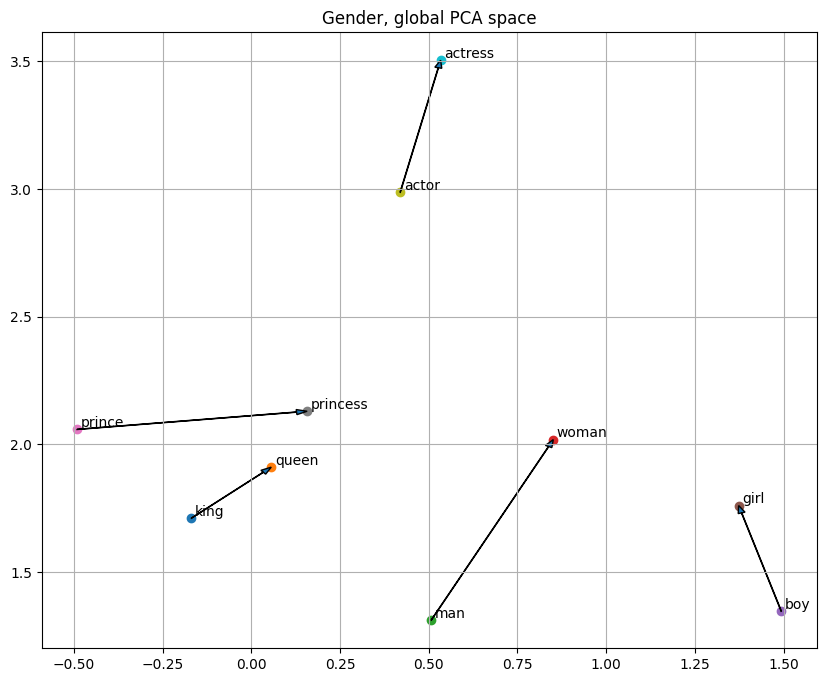

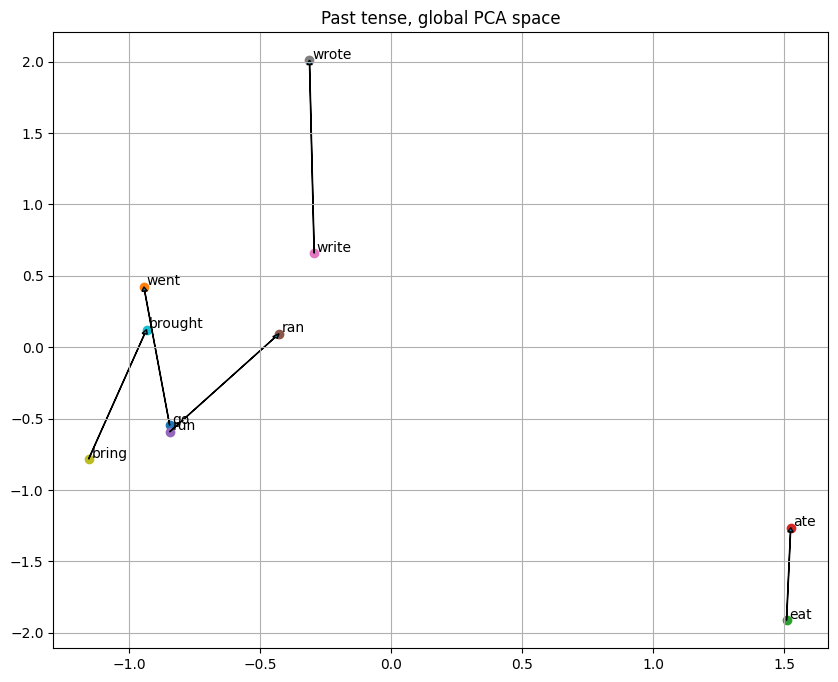

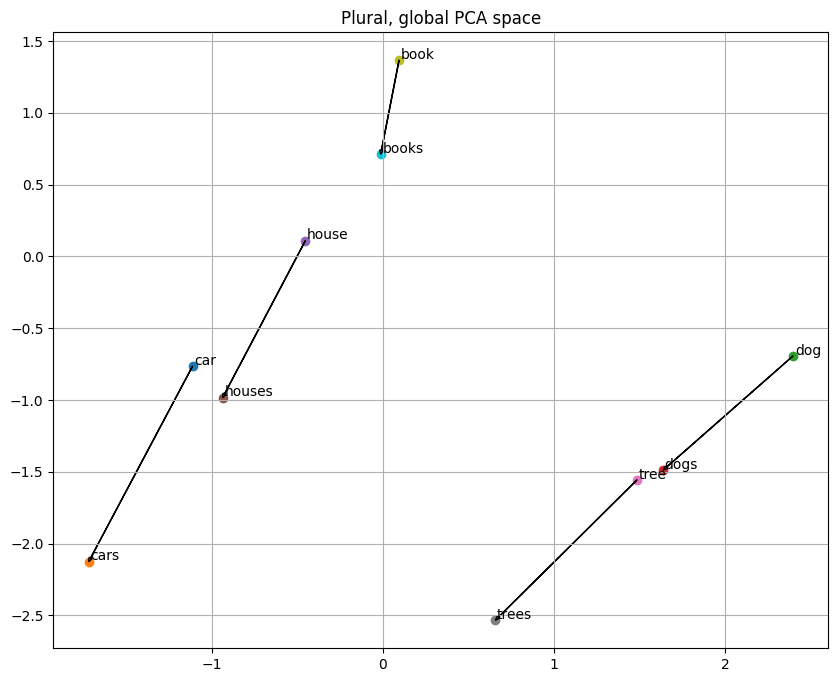

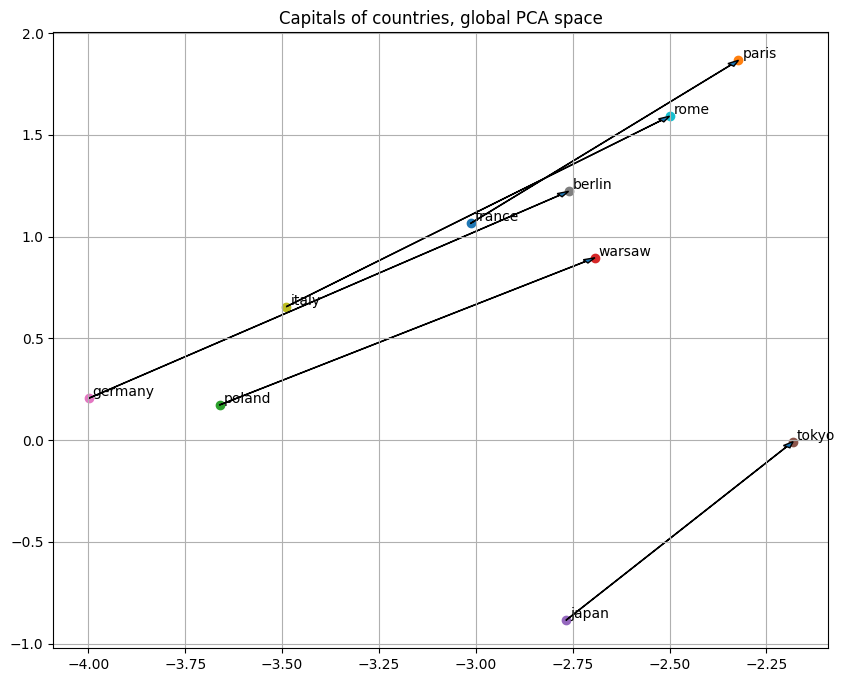

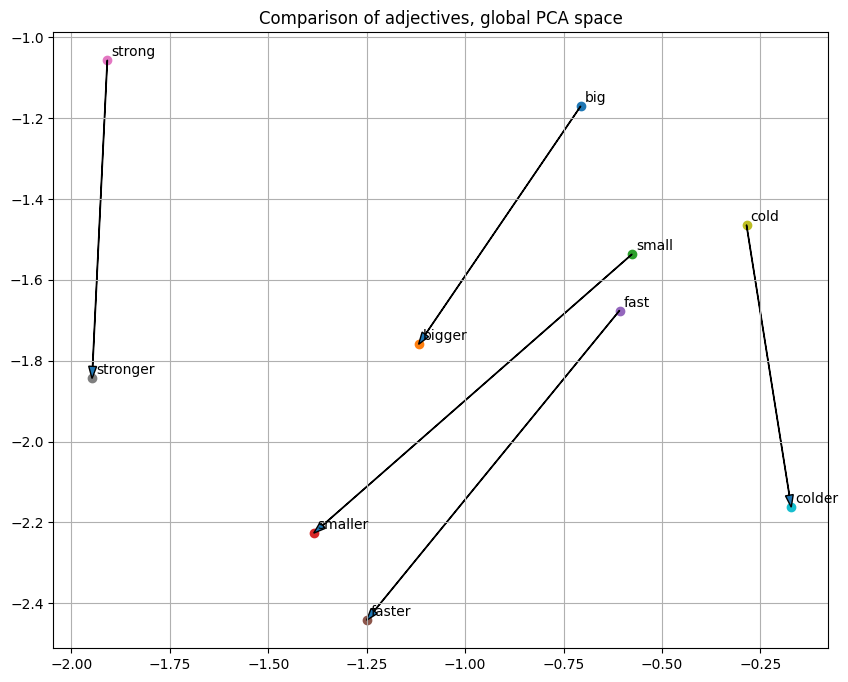

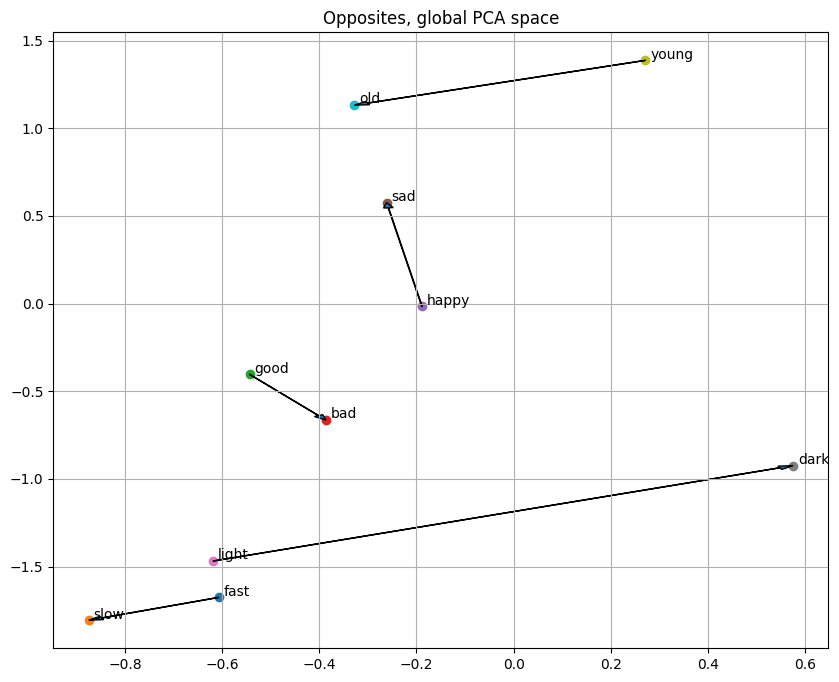

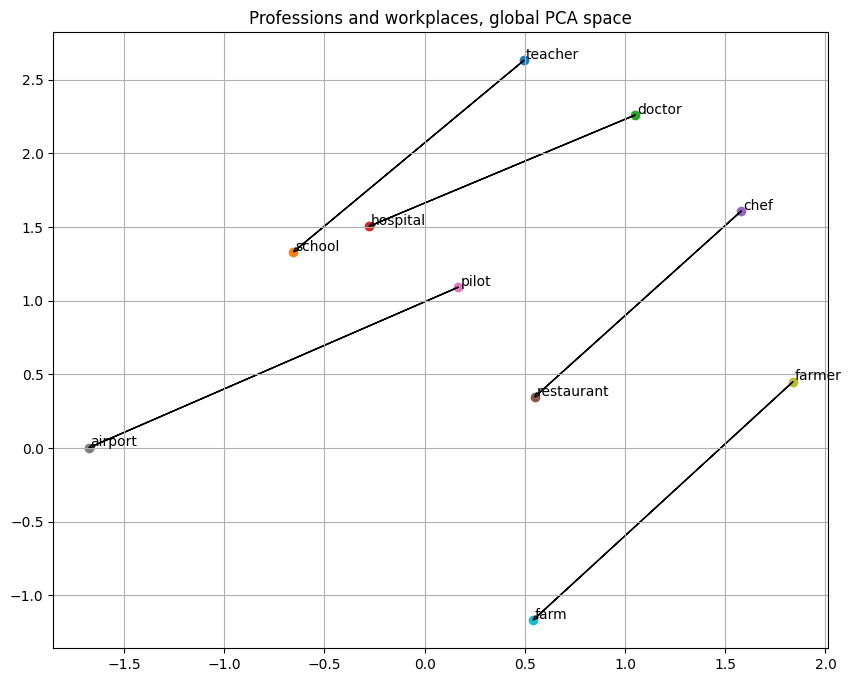

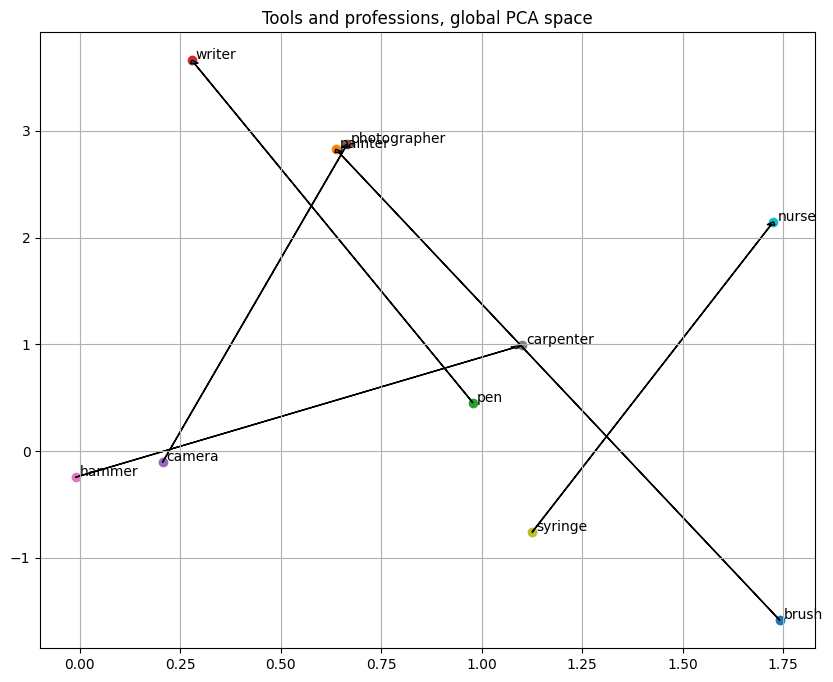

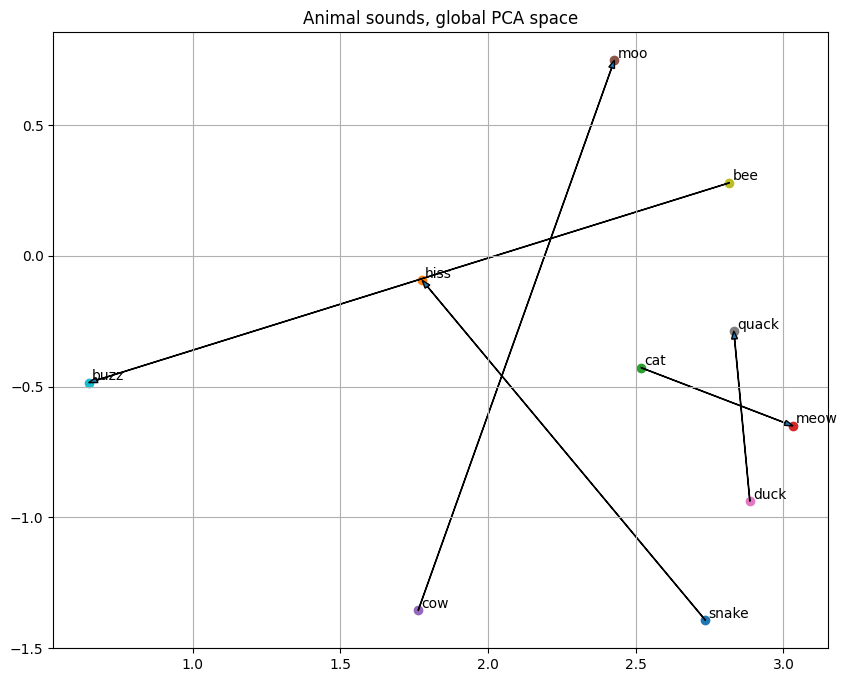

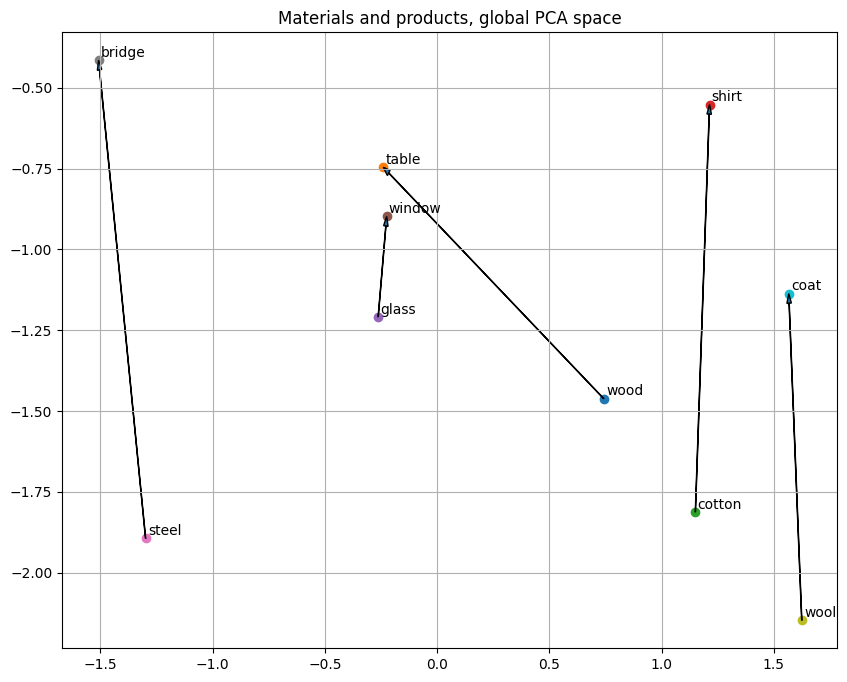

In [53]:
for class_name, pairs in classes.items():
    class_words = []

    for a, b in pairs:
        class_words.extend([a, b])

    indices = [all_words.index(w) for w in class_words]

    coords = global_2d[indices]

    plot_pairs(
        class_words,
        coords,
        pairs,
        f"{class_name}, global PCA space"
    )

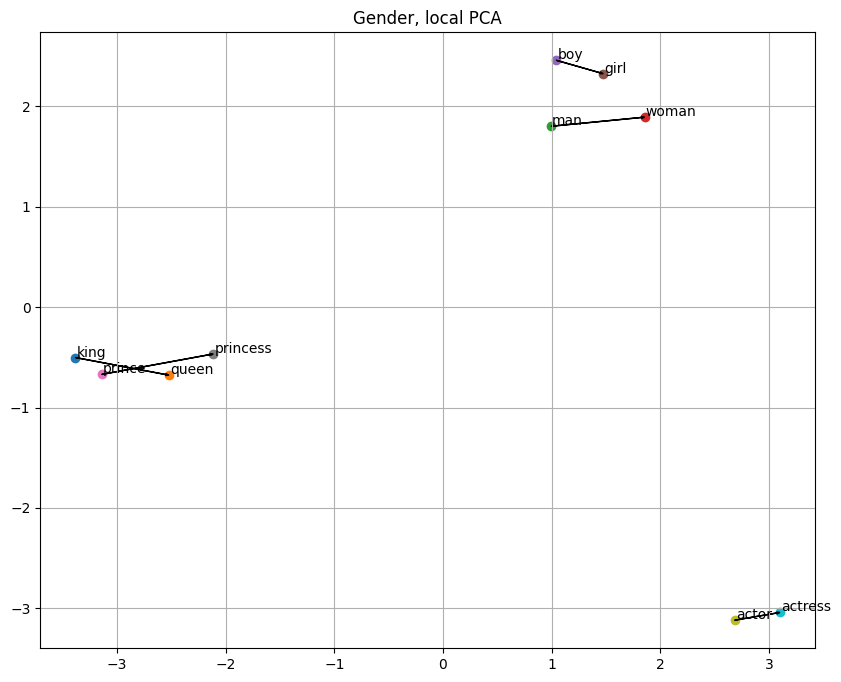

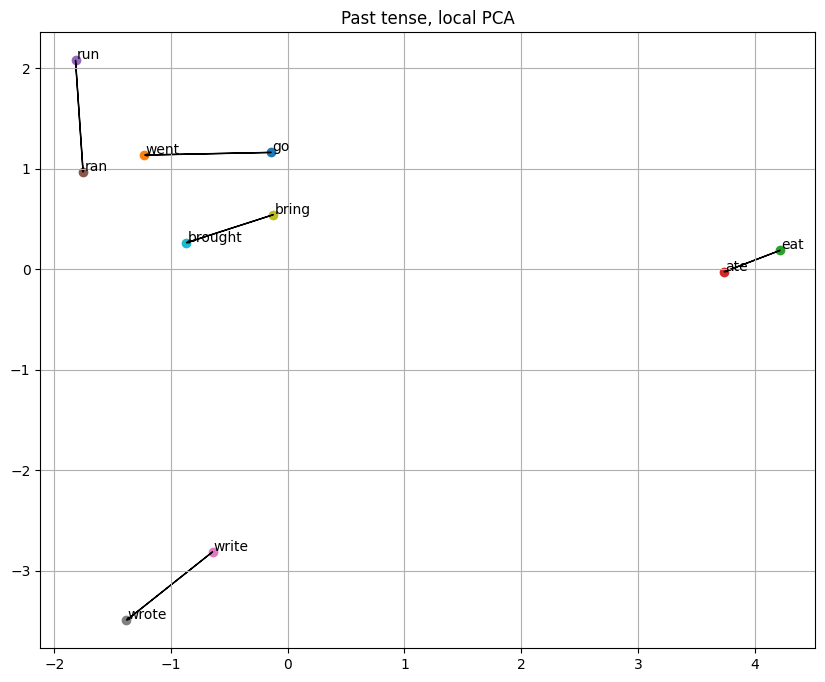

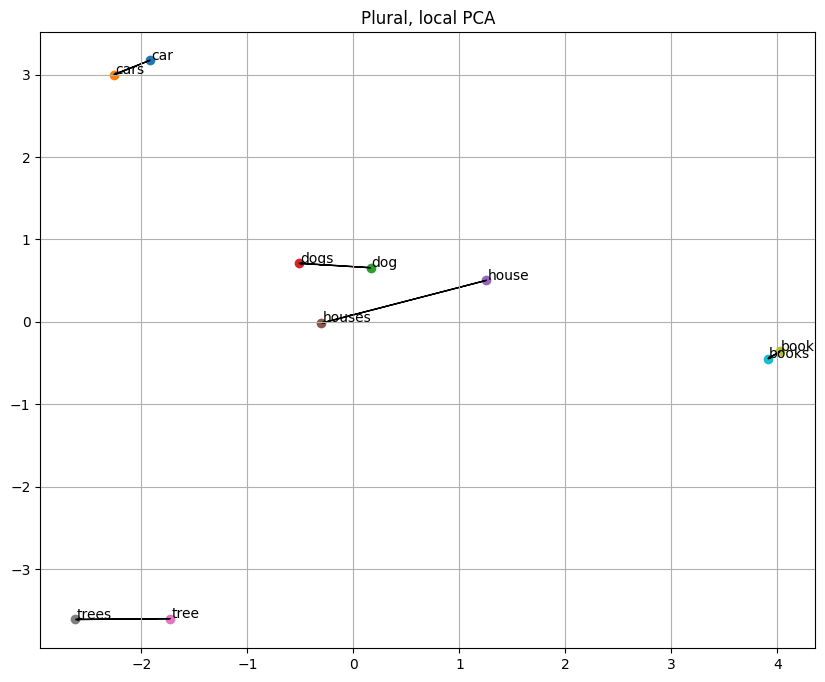

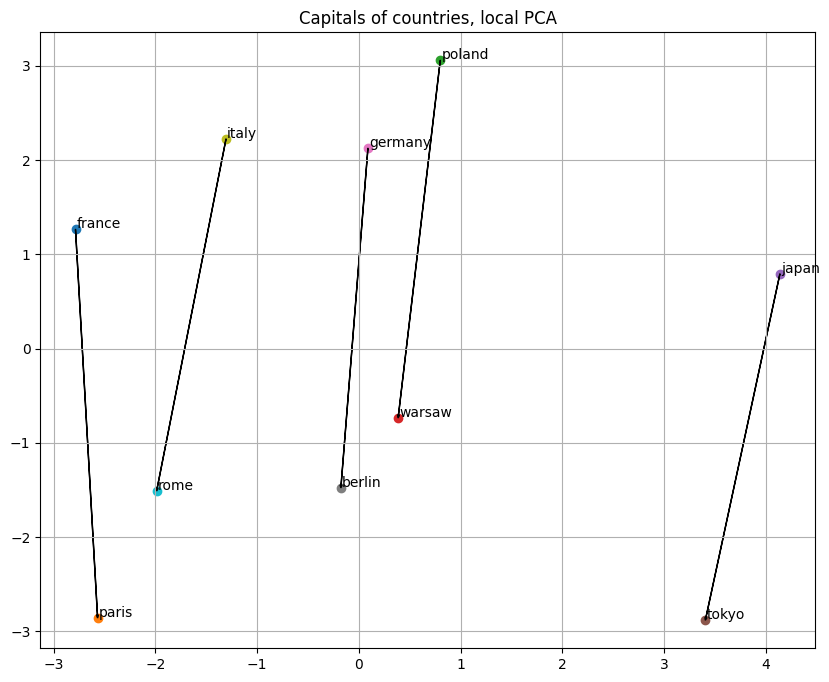

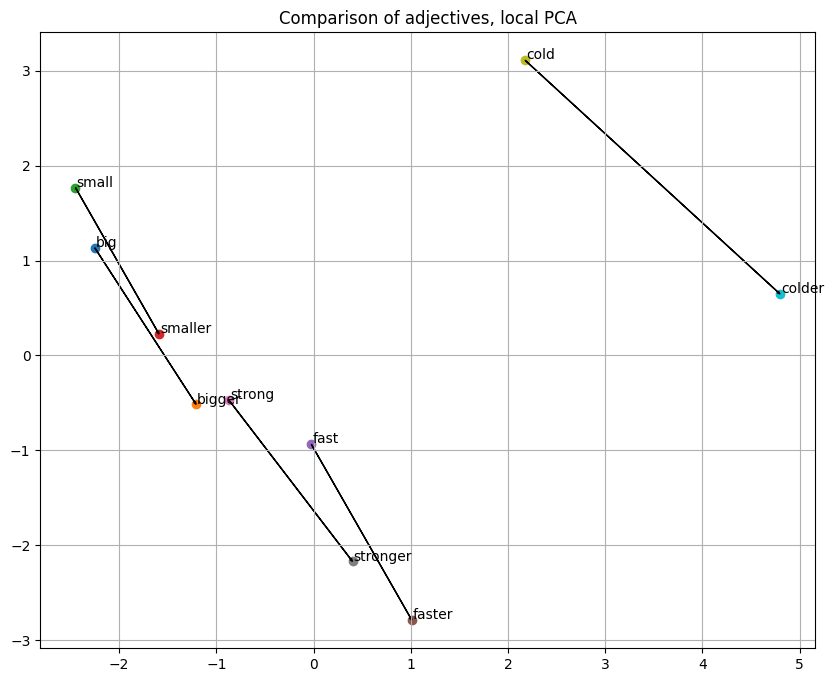

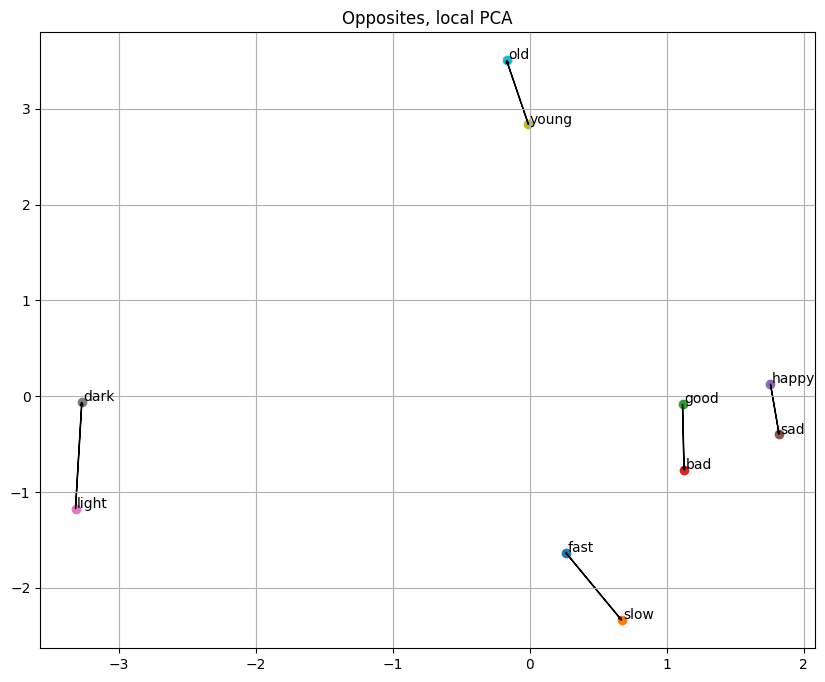

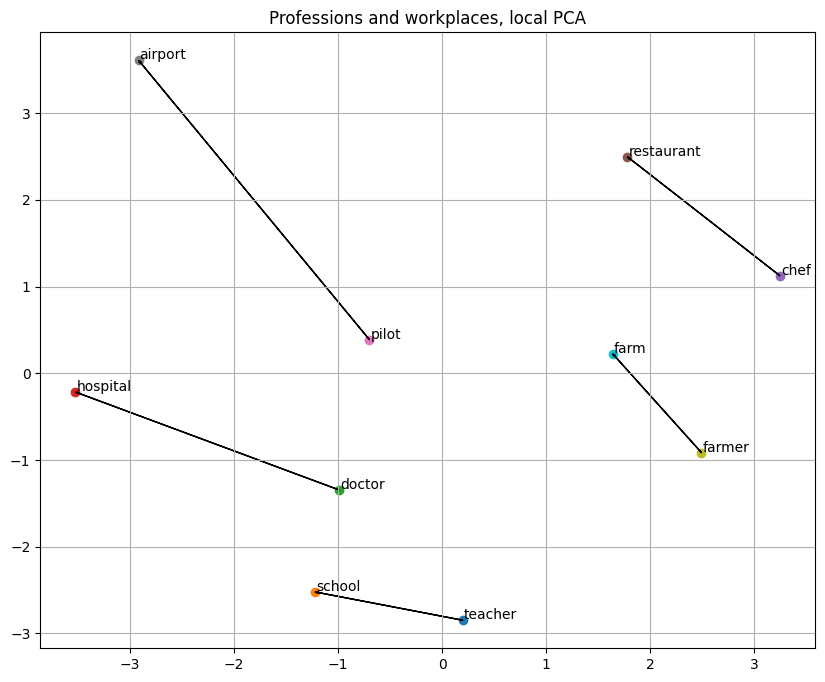

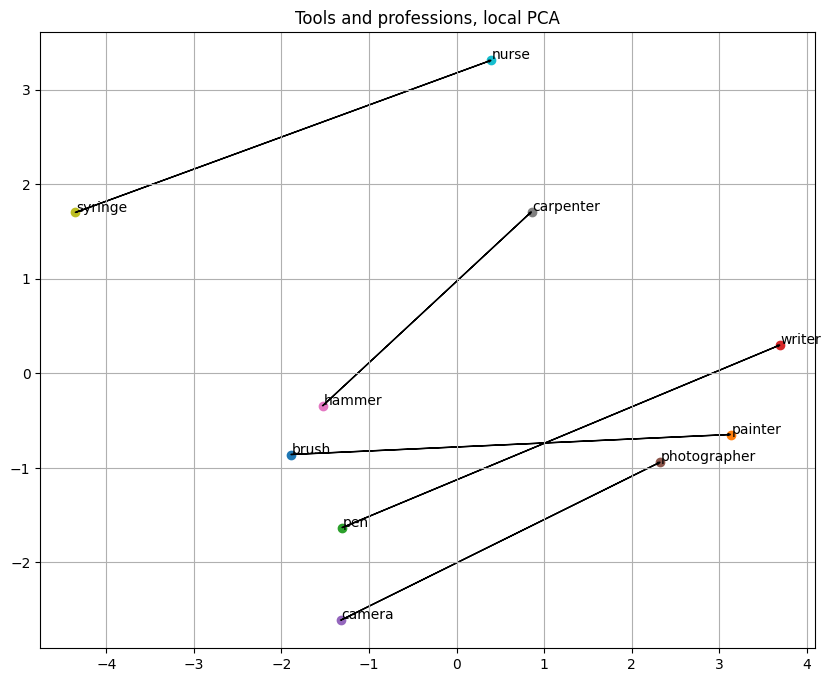

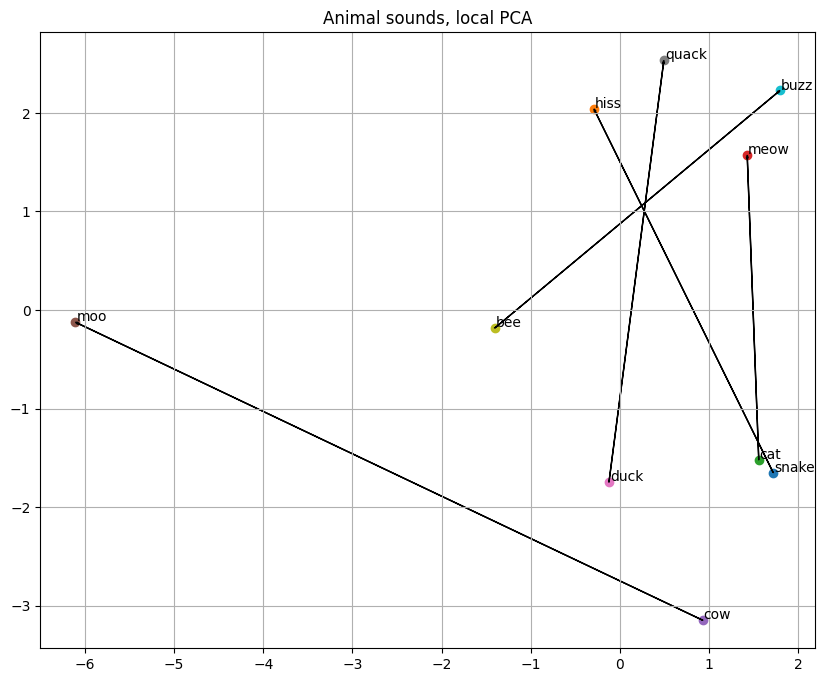

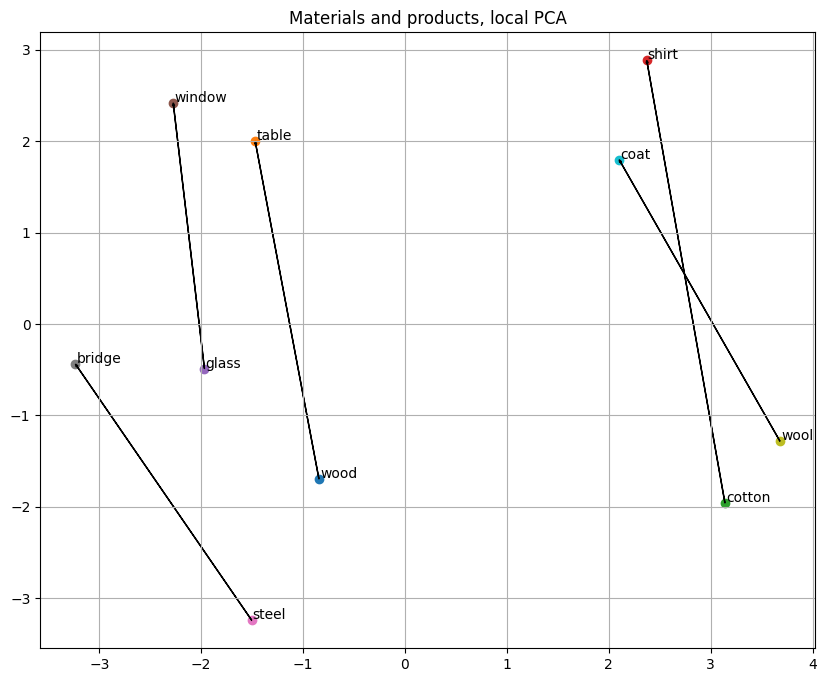

In [54]:
for class_name, pairs in classes.items():
    class_words = []

    for a, b in pairs:
        class_words.extend([a, b])

    class_embeddings = np.array([
        model[w] for w in class_words
    ])

    pca_local = PCA(n_components=2)

    coords_local = pca_local.fit_transform(class_embeddings)

    plot_pairs(
        class_words,
        coords_local,
        pairs,
        f"{class_name}, local PCA"
    )

In [55]:
import numpy as np

all_vectors = model.vectors
all_norms = np.linalg.norm(all_vectors, axis=1)

def closest_words(a, b, c, topn=5):
    target = model[b] - model[a] + model[c]
    target_norm = np.linalg.norm(target)
    sims = np.dot(all_vectors, target) / (all_norms * target_norm)

    best_idx = np.argsort(-sims)

    print(f"\n{b} - {a} + {c}")

    shown = 0
    for idx in best_idx:
        word = model.index_to_key[idx]
        if word not in [a, b, c]:
            print(f"{word:15} {sims[idx]:.4f}")
            shown += 1
            if shown >= topn:
                break

In [56]:
closest_words("man", "king", "woman")
closest_words("eat", "ate", "go")
closest_words("dog", "dogs", "car")
closest_words("poland", "warsaw", "france")
closest_words("small", "smaller", "big")
closest_words("good", "bad", "young")
closest_words("chef", "restaurant", "doctor")
closest_words("syringe", "nurse", "camera")
closest_words("cow", "moo", "duck")
closest_words("glass", "window", "steel")


king - man + woman
queen           0.7834
monarch         0.6934
throne          0.6833
daughter        0.6809
prince          0.6713

ate - eat + go
went            0.8447
came            0.7982
gone            0.7913
got             0.7724
going           0.7484

dogs - dog + car
cars            0.8827
vehicles        0.8367
truck           0.7824
vehicle         0.7801
trucks          0.7713

warsaw - poland + france
paris           0.8761
french          0.7557
prohertrib      0.6928
brussels        0.6718
lyon            0.6403

smaller - small + big
bigger          0.8572
biggest         0.6951
larger          0.6659
even            0.6656
competitors     0.6468

bad - good + young
teenage         0.6926
younger         0.6526
boys            0.6472
teenagers       0.6465
teen            0.6413

restaurant - chef + doctor
hospital        0.8072
clinic          0.7101
medical         0.6812
patient         0.6768
doctors         0.6598

nurse - syringe + camera
watch           0.

In this task I've used the GloVE embeddings with a vocabulary of 1.2M words.

PCA partially preserves the semantics. The words from the same classes tend to cluster together. For example the capitals cluster on the left, the animals on the right. Some relationships become visible as directions. For global PCA is especially visible for singulars/plurals, contries/capitals and professions/wokrplaces. When using local PCA this phenomenon is even more visible.

The embedding arithmetic produces words that are relevant. Indeed king-man+woman = queen. Noticably I got bad-good+young=teenage and the word 'old' is not even in the top 5. Also no proper word was found for moo-cow+duck.

It seems that the relationships that are captured best are related to grammar or the pairs of word often occur together. Examples of those are:
 - plurals
 - tense
 - gender
 - countries/capitals
I found these classes to work best.

The relationships that are based on symbolic logic or multi step reasoning perform worse. Such relationships I consider:
 - opposites
 - materials/products
 - animal sounds

### "What does the fox say?"

In [57]:
closest_words("cow", "moo", "fox")


moo - cow + fox
tohk            0.5435
shahl           0.5355
zahn            0.5212
fohg            0.5154
trahlt          0.5114
